# In vivo temperature measurements analysis

In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *

### Inputs

In [3]:
dataroot = '/Users/tlemaire/Documents/data/US_thermal_experiments'
datadir = os.path.join(dataroot, '20260911_M02')

### Load data

 2026/09/14 16:34:33: loading info from "/Users/tlemaire/Documents/data/US_thermal_experiments/20260911_M02/v1_center_300um" recording
 2026/09/14 16:34:33: getting sample rate from info.rhd header
 2026/09/14 16:34:33: sample rate: 20000.0 Hz
 2026/09/14 16:34:33: getting sample count and analog channel count from file sizes
 2026/09/14 16:34:33: sample count: 18714960, analog channel count: 1
 2026/09/14 16:34:33: loading analogin.dat as memmap
 2026/09/14 16:34:33: downsampling channel 0 from 20000.0 Hz to 119.760 Hz
 2026/09/14 16:34:33: converting downsampled ADC vector to volts
 2026/09/14 16:34:33: generating downsampled time vector
 2026/09/14 16:34:33: converting Osensa probe voltage to degC
 2026/09/14 16:34:33: Lowpass filtering temperature trace at 30 Hz
 2026/09/14 16:34:33: plotting longitudinal temperature recording at 3.992 Hz
 2026/09/14 16:34:33: loading digitalin.dat as memmap
 2026/09/14 16:34:33: no digitalin line specified, checking all lines for rising edges
 202

T (°C)                  timestamp  \
location         trial time (s)                                          
v1_center_300um  0     -0.491925  20.781502 2026-09-11 11:22:39.624068   
                       -0.483575  20.780222 2026-09-11 11:22:39.624068   
                       -0.475225  20.779195 2026-09-11 11:22:39.624068   
                       -0.466875  20.779979 2026-09-11 11:22:39.624068   
                       -0.458525  20.780100 2026-09-11 11:22:39.624068   
...                                     ...                        ...   
v1_center_1300um 179    5.127275  21.108135 2026-09-11 11:56:32.799128   
                        5.135625  21.107597 2026-09-11 11:56:32.799128   
                        5.143975  21.107487 2026-09-11 11:56:32.799128   
                        5.152325  21.107075 2026-09-11 11:56:32.799128   
                        5.160675  21.104752 2026-09-11 11:56:32.799128   

                                  Fdrive (MHz)  P (MPa)   Vpp (V)  tstim (s)  \
location         trial time (s)                                                
v1_center_300um  0     -0.491925         2.095      0.4  0.127648        0.2   
                       -0.483575         2.095      0.4  0.127648        0.2   
                       -0.475225         2.095      0.4  0.127648        0.2   
                       -0.466875         2.095      0.4  0.127648        0.2   
                       -0.458525         2.095      0.4  0.127648        0.2   
...                                        ...      ...       ...        ...   
v1_center_1300um 179    5.127275         2.095      0.4  0.127648        0.2   
                        5.135625         2.095      0.4  0.127648        0.2   
                        5.143975         2.095      0.4  0.127648        0.2   
                        5.152325         2.095      0.4  0.127648        0.2   
                        5.160675         2.095      0.4  0.127648        0.2   

                                  PRF (Hz)  DC (%)  elapsed time (s)  
location         trial time (s)                                       
v1_center_300um  0     -0.491925     100.0    80.0          0.000000  
                       -0.483575     100.0    80.0          0.000000  
                       -0.475225     100.0    80.0          0.000000  
                       -0.466875     100.0    80.0          0.000000  
                       -0.458525     100.0    80.0          0.000000  
...                                    ...     ...               ...  
v1_center_1300um 179    5.127275     100.0    80.0        882.071274  
                        5.135625     100.0    80.0        882.071274  
                        5.143975     100.0    80.0        882.071274  
                        5.152325     100.0    80.0        882.071274  
                        5.160675     100.0    80.0        882.071274  

[289077 rows x 9 columns]

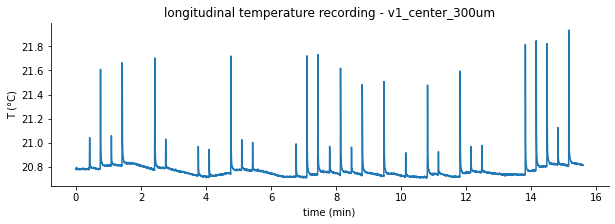

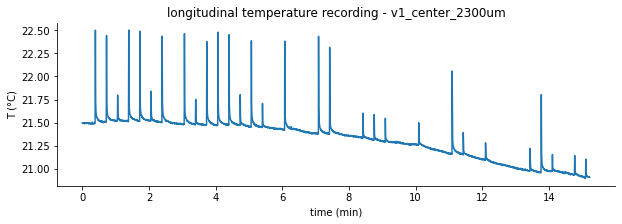

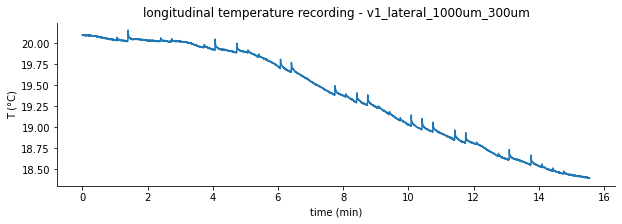

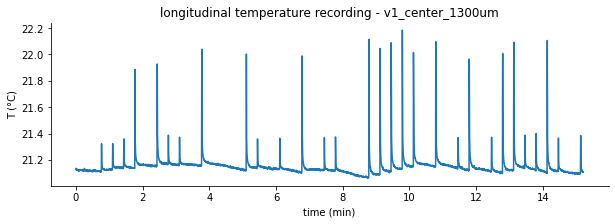

In [4]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadir, plot=True).rename_axis(index={'condition': 'location'})

logger.info('processed experiment data:')
data

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [5]:
# Restrict trial data to up to 5s post-stimulation
logger.info('restricting trial data to up to 5s post-stimulation')
data = data[data.index.get_level_values(TIME_KEY) < 5.].copy()

# Apply trial-by-trial linear detrending to the temperature data
logger.info('detrending temperature traces trial-by-trial')
data[f'detrended {TEMP_KEY}'] = (
    data
    .groupby('trial')
    [TEMP_KEY]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[REL_TEMP_KEY] = (
    data
    .groupby('trial')
    [f'detrended {TEMP_KEY}']
    .transform(compute_deltaT)
)

data

 2026/09/14 16:34:36: restricting trial data to up to 5s post-stimulation
 2026/09/14 16:34:36: detrending temperature traces trial-by-trial
 2026/09/14 16:34:36: computing trial-by-trial relative temperature change


T (°C)                  timestamp  \
location         trial time (s)                                          
v1_center_300um  0     -0.491925  20.781502 2026-09-11 11:22:39.624068   
                       -0.483575  20.780222 2026-09-11 11:22:39.624068   
                       -0.475225  20.779195 2026-09-11 11:22:39.624068   
                       -0.466875  20.779979 2026-09-11 11:22:39.624068   
                       -0.458525  20.780100 2026-09-11 11:22:39.624068   
...                                     ...                        ...   
v1_center_1300um 179    4.960275  21.103799 2026-09-11 11:56:32.799128   
                        4.968625  21.105902 2026-09-11 11:56:32.799128   
                        4.976975  21.106443 2026-09-11 11:56:32.799128   
                        4.985325  21.104264 2026-09-11 11:56:32.799128   
                        4.993675  21.103978 2026-09-11 11:56:32.799128   

                                  Fdrive (MHz)  P (MPa)   Vpp (V)  tstim (s)  \
location         trial time (s)                                                
v1_center_300um  0     -0.491925         2.095      0.4  0.127648        0.2   
                       -0.483575         2.095      0.4  0.127648        0.2   
                       -0.475225         2.095      0.4  0.127648        0.2   
                       -0.466875         2.095      0.4  0.127648        0.2   
                       -0.458525         2.095      0.4  0.127648        0.2   
...                                        ...      ...       ...        ...   
v1_center_1300um 179    4.960275         2.095      0.4  0.127648        0.2   
                        4.968625         2.095      0.4  0.127648        0.2   
                        4.976975         2.095      0.4  0.127648        0.2   
                        4.985325         2.095      0.4  0.127648        0.2   
                        4.993675         2.095      0.4  0.127648        0.2   

                                  PRF (Hz)  DC (%)  elapsed time (s)  \
location         trial time (s)                                        
v1_center_300um  0     -0.491925     100.0    80.0          0.000000   
                       -0.483575     100.0    80.0          0.000000   
                       -0.475225     100.0    80.0          0.000000   
                       -0.466875     100.0    80.0          0.000000   
                       -0.458525     100.0    80.0          0.000000   
...                                    ...     ...               ...   
v1_center_1300um 179    4.960275     100.0    80.0        882.071274   
                        4.968625     100.0    80.0        882.071274   
                        4.976975     100.0    80.0        882.071274   
                        4.985325     100.0    80.0        882.071274   
                        4.993675     100.0    80.0        882.071274   

                                  detrended T (°C)   ΔT (°C)  
location         trial time (s)                               
v1_center_300um  0     -0.491925         20.790944  0.000495  
                       -0.483575         20.789642 -0.000807  
                       -0.475225         20.788594 -0.001855  
                       -0.466875         20.789356 -0.001093  
                       -0.458525         20.789456 -0.000994  
...                                            ...       ...  
v1_center_1300um 179    4.960275         21.099276 -0.008480  
                        4.968625         21.101359 -0.006397  
                        4.976975         21.101879 -0.005877  
                        4.985325         21.099679 -0.008077  
                        4.993675         21.099371 -0.008385  

[118440 rows x 11 columns]

### Aggregate traces across trials for each condition 

In [6]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/14 16:34:37: computing trial-average data by ['location', 'P (MPa)']


PRF (Hz)  DC (%)  tstim (s)  \
location                P (MPa) time (s)                                 
v1_center_1300um        0.0     -0.492275     100.0    80.0        0.2   
                                -0.483925     100.0    80.0        0.2   
                                -0.475575     100.0    80.0        0.2   
                                -0.467225     100.0    80.0        0.2   
                                -0.458875     100.0    80.0        0.2   
...                                             ...     ...        ...   
v1_lateral_1000um_300um 0.8      4.960475     100.0    80.0        0.2   
                                 4.968825     100.0    80.0        0.2   
                                 4.977175     100.0    80.0        0.2   
                                 4.985525     100.0    80.0        0.2   
                                 4.993875     100.0    80.0        0.2   

                                            Vpp (V)  detrended T (°C)  \
location                P (MPa) time (s)                                
v1_center_1300um        0.0     -0.492275  0.000000         21.135713   
                                -0.483925  0.000000         21.134898   
                                -0.475575  0.000000         21.134494   
                                -0.467225  0.000000         21.135002   
                                -0.458875  0.000000         21.135334   
...                                             ...               ...   
v1_lateral_1000um_300um 0.8      4.960475  0.257133         19.272212   
                                 4.968825  0.257133         19.271883   
                                 4.977175  0.257133         19.271590   
                                 4.985525  0.257133         19.272219   
                                 4.993875  0.257133         19.272437   

                                            ΔT (°C)     T (°C)  Fdrive (MHz)  
location                P (MPa) time (s)                                      
v1_center_1300um        0.0     -0.492275  0.001102  21.138446         2.095  
                                -0.483925  0.000286  21.137625         2.095  
                                -0.475575 -0.000117  21.137215         2.095  
                                -0.467225  0.000390  21.137716         2.095  
                                -0.458875  0.000722  21.138042         2.095  
...                                             ...        ...           ...  
v1_lateral_1000um_300um 0.8      4.960475 -0.005766  19.282024         2.095  
                                 4.968825 -0.006095  19.281741         2.095  
                                 4.977175 -0.006388  19.281493         2.095  
                                 4.985525 -0.005759  19.282168         2.095  
                                 4.993875 -0.005542  19.282431         2.095  

[7896 rows x 8 columns]

### Fit double exponential to temperature data

 2026/09/14 16:34:37: fitting double exponential to trial-averaged temperature traces
 2026/09/14 16:34:37: constructing fitted double exponential traces
 2026/09/14 16:34:37: plotting t0 distribution
 2026/09/14 16:34:37: plotting peak distribution
 2026/09/14 16:34:37: plotting tau_rise distribution
 2026/09/14 16:34:37: plotting tau_decay distribution
 2026/09/14 16:34:37: plotting offset distribution


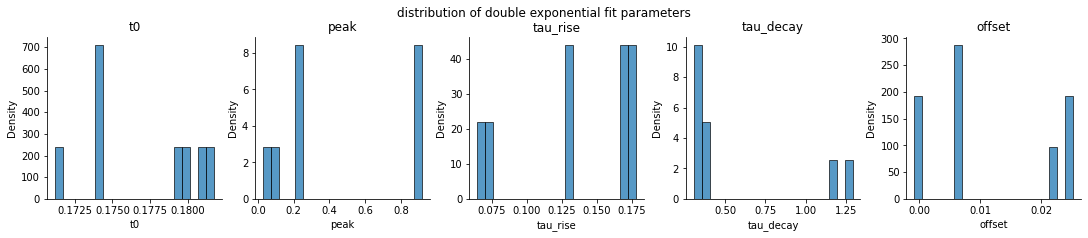

In [7]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = [k for k in aggdata.index.names if k != TIME_KEY]
groups = aggdata.groupby(gby)[REL_TEMP_KEY]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {REL_TEMP_KEY}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(TIME_KEY).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(TIME_KEY))
)

naxes = len(fits.columns)
fig, axes = plt.subplots(1, naxes, figsize=(3 * naxes, 3), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.histplot(
        fits[k],
        ax=ax,
        bins=20,
        stat='density',
    )
    ax.set_title(k)
    sns.despine(ax=ax)
    fig.suptitle('distribution of double exponential fit parameters', y=1.05)

### Plot stim-evoked temperature trace 

 2026/09/14 16:34:38: plotting stimulus-evoked temperature traces per location


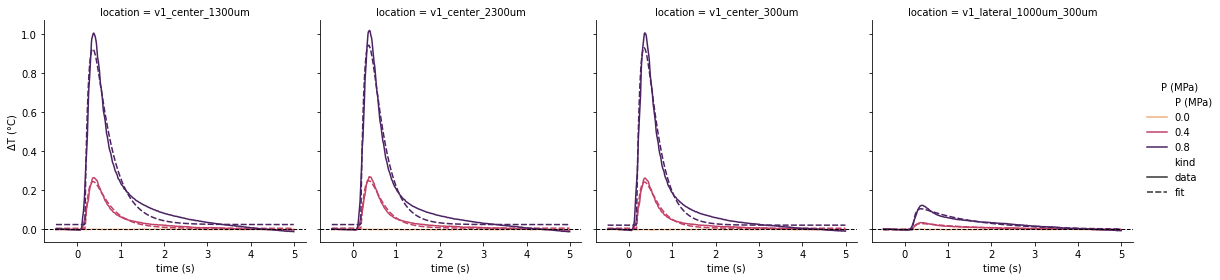

In [8]:
# Melt data by data/fit kind for plotting
ymap = {
    REL_TEMP_KEY: 'data',
    f'fitted {REL_TEMP_KEY}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
hue = Label.P
logger.info(f'plotting stimulus-evoked temperature traces per location')
g = sns.FacetGrid(
    data=melted_data.reset_index(),
    col='location',
    height=4,
    sharex=False,
)
g.map_dataframe(
    plot_evoked_thermal_response,
    y=REL_TEMP_KEY,
    errorbar='se',
    hue=hue,
    palette='flare',
    style='kind',
)
g.add_legend(title=hue)

### Compute max-evoked temperature change for each condition

In [9]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(list(data.columns) + list(data.index.names))
logger.info('computing max-evoked temperature change for each condition and trial')
max_evoked_change = (
    data
    .groupby([*cond_keys, 'trial'])
    [REL_TEMP_KEY]
    .max()
    .rename(MAX_REL_TEMP_KEY)
)
max_evoked_change

logger.info('computing average max-evoked temperature change for each condition')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

 2026/09/14 16:34:40: computing max-evoked temperature change for each condition and trial
 2026/09/14 16:34:40: computing average max-evoked temperature change for each condition


### Plot dose-dependence of evoked temperature change at each location

 2026/09/14 16:34:40: plotting pressure dependence of temperature change at v1_center_300um
 2026/09/14 16:34:40: plotting pressure-dependent evoked temperature change traces
 2026/09/14 16:34:41: performing quadratic fit on max_ΔT vs pressure
 2026/09/14 16:34:41: plotting dose-dependence of max-evoked temperature change at focus
 2026/09/14 16:34:41: plotting pressure dependence of temperature change at v1_center_2300um
 2026/09/14 16:34:41: plotting pressure-dependent evoked temperature change traces
 2026/09/14 16:34:42: performing quadratic fit on max_ΔT vs pressure
 2026/09/14 16:34:42: plotting dose-dependence of max-evoked temperature change at focus
 2026/09/14 16:34:42: plotting pressure dependence of temperature change at v1_lateral_1000um_300um
 2026/09/14 16:34:42: plotting pressure-dependent evoked temperature change traces
 2026/09/14 16:34:43: performing quadratic fit on max_ΔT vs pressure
 2026/09/14 16:34:43: plotting dose-dependence of max-evoked temperature change a

Text(0.5, 1.05, 'max-evoked temperature change vs. pressure')

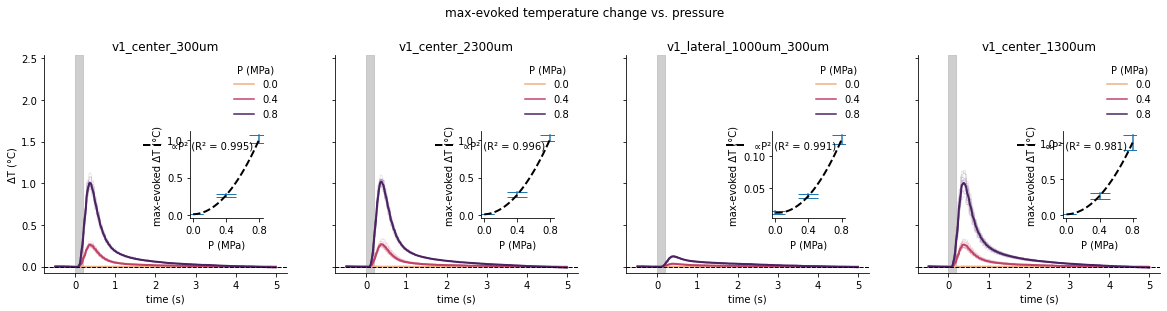

In [10]:
# Plot pressure dependence of temperature change at each location, with quadratic fit and R² value
locs = data.index.unique('location')
naxes = len(locs)
fig, axes = plt.subplots(1, naxes, figsize=(5 * naxes, 4), sharey=True)
for loc, ax in zip(data.index.unique('location'), axes):
    logger.info(f'plotting pressure dependence of temperature change at {loc}')
    loc_data = data.loc[loc]
    loc_max_evoked_change = max_evoked_change.loc[loc]
    plot_pressure_dependence(
        loc_data, loc_max_evoked_change, title=loc, ax=ax)
fig.suptitle('max-evoked temperature change vs. pressure', y=1.05)